# Deep Reinforcement Learning: Source-Matched DDPG for Continuous LunarLander

This notebook is a self-contained portfolio implementation of the supplied `DeepDPG` source code for continuous LunarLander.

The external `deep_rl` package is not required.

The implementation preserves the supplied source behavior for:

- `DeepDPG`,
- `ExperienceReplay`,
- actor/critic learning,
- target-network updates,
- exploration probability,
- replay sampling,
- `AverageQMetric`,
- `AbsoluteValueErrorMetric`,
- training frequency,
- and model/replay saving.

The original experiment used `LunarLander-v2`. Current Gymnasium uses `LunarLander-v3`, so this notebook uses:

```python
gym.make("LunarLander-v3", continuous=True)
```

The state/action structure remains compatible with the supplied neural networks.

## 1. Important wrapper behavior from the supplied source

The exact `LunarLanderContinuousEnvironment` source was supplied.

It inherits from the project's base `GymEnvironment`.

The base class defines:

```python
def get_random_action(self):
    return self.env.action_space.sample()
```

The LunarLander subclass defines a different method:

```python
def get_randomized_action(self):
    ...
```

that generates Ornstein-Uhlenbeck noise.

However, the supplied `DeepDPG.get_action()` calls:

```python
self.env.get_random_action()
```

not:

```python
self.env.get_randomized_action()
```

Therefore the OU method is **never called by the supplied DDPG algorithm**.

The actual exploration behavior is:

$$
\boxed{
A_t
=
\mu(S_t)
+
A_t^{\mathrm{random}}
}
$$

where the random action comes from the Gym/Gymnasium action space.

The wrapper then clips the combined action to:

$$
\boxed{
[-1,1]^2
}
$$

before sending it to LunarLander.

## 2. Continuous LunarLander state

The observation has eight values:

$$
\boxed{
S_t=
[x,\ y,\ v_x,\ v_y,\ \theta,\ \dot{\theta},\ c_L,\ c_R]
}
$$

where the variables describe position, velocity, orientation, angular velocity, and leg contact.

Therefore the actor input dimension is

$$
\boxed{8}.
$$

## 3. Continuous action

The action contains two continuous values:

$$
\boxed{
A_t=[a_{\text{main}},a_{\text{lateral}}]
}
$$

with each actor output produced by a `tanh` activation.

Therefore:

$$
\boxed{
A_t\in[-1,1]^2.
}
$$

## 4. Reward

Because the exact custom wrapper source was not supplied, this notebook uses the native Gymnasium continuous LunarLander reward through the same base behavior as:

```python
def calculate_reward(self):
    return self.reward
```

No extra reward shaping is added in this notebook.

This is intentionally different from guessing an undocumented custom reward.

## 5. Actor network

The supplied actor architecture is:

$$
\boxed{
8\rightarrow256\rightarrow256\rightarrow256\rightarrow2
}
$$

Each hidden layer uses ReLU followed by Batch Normalization.

The output layer uses `tanh`.

The final-layer initializer is:

$$
W\sim U(-0.003,0.003).
$$

The actor learning rate is:

$$
\boxed{0.0005}.
$$

## 6. Critic network

The supplied critic has two inputs.

State branch:

$$
\boxed{
8\rightarrow192
}
$$

followed by Batch Normalization.

Action branch:

$$
\boxed{
2\rightarrow64
}
$$

The branches are concatenated and passed through:

$$
\boxed{
256\rightarrow256\rightarrow1.
}
$$

The critic learning rate is:

$$
\boxed{0.001}.
$$

## 7. Source-faithful replay behavior

The supplied `ExperienceReplay` samples random indices **with replacement**.

If replay contains fewer transitions than the requested batch size, it returns only the transitions currently available.

For this experiment:

$$
\boxed{\text{batch size}=64}
$$

and

$$
\boxed{\text{replay capacity}=100,000}.
$$

## 8. What `learn_after_steps = 4` means

The supplied LunarLander experiment used:

```python
learn_after_steps=4
```

The source checks:

```python
if self.step_counter % self.learn_after_steps == 0:
```

Therefore this means:

$$
\boxed{\text{attempt one learning update every 4 environment steps}}
$$

not "wait for four experiences."

A gradient update occurs only when replay can provide the complete 64-transition batch.

Therefore the first possible update occurs after at least 64 transitions are stored.

## 9. Source-faithful exploration

The supplied `DeepDPG.get_action()` first calculates:

$$
A_t=\mu(S_t).
$$

Then, with probability `exploration`, it executes:

```python
action = action + self.env.get_random_action()
```

The supplied experiment uses:

$$
\boxed{\text{exploration}=1.0}
$$

and:

$$
\boxed{\text{exploration decay}=1.0}.
$$

Therefore an exploration action is added on every training step.

Because `LunarLanderContinuousEnvironment` does **not** override `get_random_action()`, Python uses the inherited base implementation:

```python
def get_random_action(self):
    return self.env.action_space.sample()
```

The wrapper's OU method is named:

```python
get_randomized_action()
```

and is not called by `DeepDPG`.

Therefore:

$$
\boxed{
A_t
=
\mu(S_t)
+
A_t^{\mathrm{sample}}
}
$$

and the environment receives:

$$
\boxed{
A_t^{\mathrm{env}}
=
\operatorname{clip}(A_t,-1,1).
}
$$

Replay memory stores the combined action before the wrapper clips it.

## 10. Source-faithful critic target

The supplied `DeepDPG` source computes:

$$
\boxed{
Y_t
=
R_{t+1}
+
\gamma
Q'
\left(
S_{t+1},
\mu'(S_{t+1})
\right)
}
$$

with:

$$
\boxed{\gamma=0.99}.
$$

The supplied source stores terminal information in replay but does not use it in this DDPG target.

This notebook reproduces that behavior.

## 11. Critic loss

The supplied source uses mean squared error:

$$
\boxed{
L_Q
=
\frac{1}{N}
\sum_i
\left[
Y_i-Q(S_i,A_i)
\right]^2.
}
$$

The previous notebook used Huber loss. This corrected notebook uses MSE to match the source.

## 12. Actor loss

The actor loss in the supplied source is:

$$
\boxed{
L_\mu
=
-\frac1N
\sum_i
Q(S_i,\mu(S_i)).
}
$$

Minimizing this loss moves the actor toward actions that receive larger critic values.

## 13. Soft target update

The supplied source performs:

$$
\boxed{
\theta'
\leftarrow
\tau\theta+(1-\tau)\theta'
}
$$

for the trainable actor and critic target weights.

For this experiment:

$$
\boxed{\tau=0.001}.
$$

## 14. Target-network initialization

The supplied source creates target networks using `clone_model()`.

It does not explicitly copy the online-network weights into the target networks immediately after construction.

This notebook reproduces that source behavior rather than automatically copying the online weights.

## 15. Source-style Average Q

The original `AverageQMetric` first obtains a fixed collection of states.

At the end of each episode it evaluates:

$$
\boxed{
\frac1M
\sum_{j=1}^{M}
Q(S_j,\mu(S_j)).
}
$$

The same fixed states are reused throughout training.

## 16. Source-style Absolute Value Error

The original metric stores each predicted action value and reward from the episode.

It reconstructs discounted return backward:

$$
\boxed{
G_t=R_{t+1}+\gamma G_{t+1}
}
$$

and reports:

$$
\boxed{
\sum_t
|G_t-Q(S_t,A_t)|.
}
$$

This is not the same as one-step TD error.

## 17. Training schedule

The supplied experiment runs:

```python
for i in range(2000):
```

so the full experiment is:

$$
\boxed{2000\text{ training episodes}.}
$$

The executable source also saves and evaluates after every episode.

That outer schedule is very expensive and is not required to preserve the DDPG learning rule.

This notebook therefore uses:

```text
EXACT_EXPERIMENT_SCHEDULE = True
    evaluate every episode
    save every episode

EXACT_EXPERIMENT_SCHEDULE = False
    evaluate every 10 episodes
    save every 100 episodes
```

The default is `False` for practical Colab runtime.

## 18. Colab setup

In [1]:
%pip -q install swig
%pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 15.1 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomUniform
from tensorflow.keras.models import clone_model
from IPython.display import display, Video
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 19. Environment wrapper matching the supplied source

The self-contained code below includes the base `GymEnvironment` and your `LunarLanderContinuousEnvironment`.

Notice that the subclass contains `get_randomized_action()` but does not override `get_random_action()`.

The supplied DDPG algorithm calls `get_random_action()`, so exploration uses `action_space.sample()` exactly as the original source does.

In [3]:
class GymEnvironment:
    def __init__(self, env):
        self.env = env
        self.terminated = False
        self.truncated = False
        self.reward = 0.0
        self.preprocessed_state = None
        self.state, _ = self.env.reset()

    def preprocess_state(self, state):
        return state

    def observe(self):
        frame = self.env.render()
        self.preprocessed_state = self.preprocess_state(self.state)
        self.reward = self.calculate_reward()
        return self.preprocessed_state, self.reward, frame

    def calculate_reward(self):
        return self.reward

    def get_random_action(self):
        return self.env.action_space.sample()

    def take_action(self, action):
        self.state, self.reward, self.terminated, self.truncated, _ = self.env.step(action)

    def is_episode_finished(self):
        return self.terminated or self.truncated

    def reset(self, seed=None):
        self.terminated = False
        self.truncated = False
        self.reward = 0.0
        self.state, _ = self.env.reset(seed=seed)
        return np.asarray(self.state, dtype=np.float32)

    def close(self):
        self.env.close()


class LunarLanderContinuousEnvironment(GymEnvironment):
    def __init__(self, env):
        super().__init__(env)
        self.theta = 0.15
        self.mean = np.zeros(2)
        self.std_dev = 0.2 * np.ones(2)
        self.dt = 1e-2
        self.x = np.zeros_like(self.mean)

    def observe(self):
        self.preprocessed_state = self.preprocess_state(self.state)
        self.reward = self.calculate_reward()
        return self.preprocessed_state, self.reward, None

    def get_randomized_action(self):
        random_term = np.random.normal(size=self.mean.shape)
        self.x = self.x + self.theta * (self.mean - self.x) * self.dt + self.std_dev * np.sqrt(self.dt) * random_term
        return self.x

    def take_action(self, action):
        action = np.clip(action, -1.0, 1.0)
        super().take_action(action)

### Verify which exploration method is actually used

The next cell confirms that `get_random_action()` is inherited from `GymEnvironment`, while `get_randomized_action()` is the separate OU method defined in the subclass.

In [4]:
test_env = LunarLanderContinuousEnvironment(gym.make("LunarLander-v3", continuous=True))
print("get_random_action:", test_env.get_random_action.__func__.__qualname__)
print("get_randomized_action:", test_env.get_randomized_action.__func__.__qualname__)
test_env.close()

get_random_action: GymEnvironment.get_random_action
get_randomized_action: LunarLanderContinuousEnvironment.get_randomized_action


## 20. Inspect the current environment

In [5]:
inspect_env = gym.make("LunarLander-v3", continuous=True)
state, info = inspect_env.reset(seed=SEED)
print("Initial state:", state)
print("Observation space:", inspect_env.observation_space)
print("Action space:", inspect_env.action_space)
print("Action low:", inspect_env.action_space.low)
print("Action high:", inspect_env.action_space.high)
inspect_env.close()

Initial state: [ 0.0023  1.4181  0.2326  0.3205 -0.0027 -0.0527  0.      0.    ]
Observation space: Box([ -2.5     -2.5    -10.     -10.      -6.2832 -10.      -0.      -0.    ], [ 2.5     2.5    10.     10.      6.2832 10.      1.      1.    ], (8,), float32)
Action space: Box(-1.0, 1.0, (2,), float32)
Action low: [-1. -1.]
Action high: [1. 1.]


## 21. Actor network

In [6]:
def build_actor():
    state_input = Input(shape=(8,))
    x = Dense(256, activation="relu")(state_input)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    output = Dense(2, activation="tanh", kernel_initializer=RandomUniform(minval=-0.003, maxval=0.003))(x)
    actor_network = Model(inputs=state_input, outputs=output)
    actor_network.compile(optimizer=Adam(learning_rate=0.0005))
    return actor_network

actor_demo = build_actor()
actor_demo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,474 (537.01 KB)

 Trainable params: 135,938 (531.01 KB)

 Non-trainable params: 1,536 (6.00 KB)

## 22. Critic network

In [7]:
def build_critic():
    state_input = Input(shape=(8,))
    state_features = Dense(192, activation="relu")(state_input)
    state_features = BatchNormalization()(state_features)
    action_input = Input(shape=(2,))
    action_features = Dense(64, activation="relu")(action_input)
    x = Concatenate()([state_features, action_features])
    x = Dense(256, activation="relu")(x)
    x = Dense(256, activation="relu")(x)
    output = Dense(1, activation="linear", kernel_initializer=RandomUniform(minval=-0.003, maxval=0.003))(x)
    critic_network = Model(inputs=[state_input, action_input], outputs=output)
    critic_network.compile(optimizer=Adam(learning_rate=0.001))
    return critic_network

critic_demo = build_critic()
critic_demo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 192)       │      1,728 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192)       │        768 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        192 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        257 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,529 (525.50 KB)

 Trainable params: 134,145 (524.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 23. Source-faithful replay buffer

In [8]:
class ExperienceReplay:
    def __init__(self, max_transitions=100000):
        self.max_transitions = max_transitions
        self.buffer = []
        self.current_index = 0

    def insert_transition(self, transition):
        index = self.current_index % self.max_transitions
        if len(self.buffer) < self.max_transitions:
            self.buffer.append(transition)
        else:
            self.buffer[index] = transition
        self.current_index += 1

    def sample_batch_transitions(self, batch_size=64):
        buffer_length = len(self.buffer)
        sample_size = buffer_length if buffer_length <= batch_size else batch_size
        sampled_indices = np.random.randint(0, buffer_length, size=sample_size)
        sampled = [self.buffer[index] for index in sampled_indices]
        current_states = np.asarray([transition[0] for transition in sampled], dtype=np.float32)
        actions = np.asarray([transition[1] for transition in sampled], dtype=np.float32)
        rewards = np.asarray([transition[2] for transition in sampled], dtype=np.float32)
        next_states = np.asarray([transition[3] for transition in sampled], dtype=np.float32)
        terminals = np.asarray([transition[4] for transition in sampled], dtype=bool)
        return current_states, actions, rewards, next_states, terminals

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        if len(self.buffer) == 0:
            return
        current_states = np.asarray([transition[0] for transition in self.buffer], dtype=np.float32)
        actions = np.asarray([transition[1] for transition in self.buffer], dtype=np.float32)
        rewards = np.asarray([transition[2] for transition in self.buffer], dtype=np.float32)
        next_states = np.asarray([transition[3] for transition in self.buffer], dtype=np.float32)
        terminals = np.asarray([transition[4] for transition in self.buffer], dtype=bool)
        np.savez_compressed(os.path.join(path, "replay.npz"), current_states=current_states, actions=actions, rewards=rewards, next_states=next_states, terminals=terminals, current_index=self.current_index)

    def load(self, path):
        replay_file = os.path.join(path, "replay.npz")
        if not os.path.exists(replay_file):
            return
        data = np.load(replay_file)
        self.buffer = []
        for state, action, reward, next_state, terminal in zip(data["current_states"], data["actions"], data["rewards"], data["next_states"], data["terminals"]):
            self.buffer.append([state, action, float(reward), next_state, bool(terminal)])
        self.current_index = int(data["current_index"])

    def __len__(self):
        return len(self.buffer)

## 24. Source-faithful DDPG

In [9]:
class DDPGAgent:
    def __init__(self, actor_network, critic_network, learn_after_steps=4, replay_size=100000, exploration=1.0, min_exploration=0.01, exploration_decay=1.0, exploration_decay_after=1, discount_factor=0.99, tau=0.001):
        self.actor_network = actor_network
        self.critic_network = critic_network
        self.actor_target_network = clone_model(self.actor_network)
        self.critic_target_network = clone_model(self.critic_network)
        self.learn_after_steps = int(learn_after_steps)
        self.replay_buffer = ExperienceReplay(replay_size)
        self.discount_factor = float(discount_factor)
        self.exploration = float(exploration)
        self.min_exploration = float(min_exploration)
        self.exploration_decay = float(exploration_decay)
        self.exploration_decay_after = int(exploration_decay_after)
        self.tau = float(tau)
        self.step_counter = 1
        self.critic_loss = tf.keras.losses.MeanSquaredError()
        self.env = None

    def set_env(self, env):
        self.env = env

    def get_action(self, state, explore=0.0):
        state_tensor = tf.convert_to_tensor(state, dtype=tf.float32)
        state_batch = tf.expand_dims(state_tensor, axis=0)
        action_batch = self.actor_network(state_batch)
        explored = False
        if np.random.uniform(0.0, 1.0) < explore:
            random_action = tf.convert_to_tensor(self.env.get_random_action(), dtype=tf.float32)
            action_batch = action_batch + random_action
            explored = True
        value_batch = self.critic_network([state_batch, action_batch])
        action = action_batch[0].numpy().astype(np.float32)
        value = float(value_batch[0][0].numpy())
        return action, value, explored

    @tf.function
    def train_step(self, current_states, actions, rewards, next_states):
        targets = tf.expand_dims(rewards, axis=1) + self.discount_factor * self.critic_target_network([next_states, self.actor_target_network(next_states)])
        with tf.GradientTape() as critic_tape:
            critic_value = self.critic_network([current_states, actions])
            critic_loss = self.critic_loss(targets, critic_value)
        critic_gradients = critic_tape.gradient(critic_loss, self.critic_network.trainable_weights)
        self.critic_network.optimizer.apply_gradients(zip(critic_gradients, self.critic_network.trainable_weights))
        with tf.GradientTape() as actor_tape:
            actor_loss = -tf.reduce_mean(self.critic_network([current_states, self.actor_network(current_states)]))
        actor_gradients = actor_tape.gradient(actor_loss, self.actor_network.trainable_weights)
        self.actor_network.optimizer.apply_gradients(zip(actor_gradients, self.actor_network.trainable_weights))
        return critic_loss, actor_loss

    def update_target_network(self, target_network, online_network):
        for target_weight, online_weight in zip(target_network.trainable_weights, online_network.trainable_weights):
            target_weight.assign(self.tau * online_weight + (1.0 - self.tau) * target_weight)

    def update_targets(self):
        self.update_target_network(self.actor_target_network, self.actor_network)
        self.update_target_network(self.critic_target_network, self.critic_network)

    def get_values(self, states):
        states_tensor = tf.convert_to_tensor(states, dtype=tf.float32)
        values = self.critic_network([states_tensor, self.actor_network(states_tensor)])
        return values.numpy().reshape(-1)

    def decay_exploration(self, episode_index):
        if (episode_index + 1) % self.exploration_decay_after == 0:
            self.exploration = self.exploration / self.exploration_decay
        if self.exploration < self.min_exploration:
            self.exploration = self.min_exploration

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.actor_network.save_weights(os.path.join(path, "actor.weights.h5"))
        self.actor_target_network.save_weights(os.path.join(path, "actor_target.weights.h5"))
        self.critic_network.save_weights(os.path.join(path, "critic.weights.h5"))
        self.critic_target_network.save_weights(os.path.join(path, "critic_target.weights.h5"))
        self.replay_buffer.save(os.path.join(path, "replay"))
        np.savez(os.path.join(path, "agent_state.npz"), exploration=self.exploration, step_counter=self.step_counter)

    def load(self, path):
        self.actor_network.load_weights(os.path.join(path, "actor.weights.h5"))
        self.actor_target_network.load_weights(os.path.join(path, "actor_target.weights.h5"))
        self.critic_network.load_weights(os.path.join(path, "critic.weights.h5"))
        self.critic_target_network.load_weights(os.path.join(path, "critic_target.weights.h5"))
        self.replay_buffer.load(os.path.join(path, "replay"))
        state_file = os.path.join(path, "agent_state.npz")
        if os.path.exists(state_file):
            data = np.load(state_file)
            self.exploration = float(data["exploration"])
            self.step_counter = int(data["step_counter"])

## 25. Fixed states for source-style Average Q

In [10]:
def collect_metric_states(agent, env, num_states=20):
    metric_states = []
    state = env.reset(seed=SEED + 1000)
    while len(metric_states) < num_states and not env.is_episode_finished():
        metric_states.append(np.asarray(state, dtype=np.float32))
        action, value, explored = agent.get_action(state, explore=0.0)
        env.take_action(action)
        state = np.asarray(env.state, dtype=np.float32)
    return np.asarray(metric_states, dtype=np.float32)

## 26. Source-style Absolute Value Error

In [11]:
def calculate_absolute_value_error(values, rewards, gamma):
    discounted_return = 0.0
    total_error = 0.0
    for value, reward in zip(reversed(values), reversed(rewards)):
        discounted_return = discounted_return * gamma + reward
        total_error += abs(discounted_return - value)
    return total_error

## 27. Deterministic evaluation

In [12]:
def evaluate_one_episode(agent, seed):
    eval_env = LunarLanderContinuousEnvironment(gym.make("LunarLander-v3", continuous=True))
    state = eval_env.reset(seed=seed)
    total_reward = 0.0
    episode_length = 0
    while not eval_env.is_episode_finished():
        action, value, explored = agent.get_action(state, explore=0.0)
        eval_env.take_action(action)
        state = np.asarray(eval_env.state, dtype=np.float32)
        total_reward += float(eval_env.reward)
        episode_length += 1
    eval_env.close()
    return total_reward, episode_length

## 28. Training configuration

In [13]:
QUICK_RUN = False
EXACT_EXPERIMENT_SCHEDULE = False
NUM_EPISODES = 100 if QUICK_RUN else 2000
BATCH_SIZE = 64
EVAL_EVERY = 1 if EXACT_EXPERIMENT_SCHEDULE else 10
SAVE_EVERY = 1 if EXACT_EXPERIMENT_SCHEDULE else 100
AGENT_PATH = "lunar_lander_cont_agent2"
actor_network = build_actor()
critic_network = build_critic()
agent = DDPGAgent(actor_network, critic_network, learn_after_steps=4, replay_size=100000, exploration=1.0, min_exploration=0.01, exploration_decay=1.0, exploration_decay_after=1, discount_factor=0.99, tau=0.001)
train_env = LunarLanderContinuousEnvironment(gym.make("LunarLander-v3", continuous=True))
agent.set_env(train_env)
metric_states = collect_metric_states(agent, train_env, num_states=20)
print("Fixed AverageQMetric states:", metric_states.shape)

Fixed AverageQMetric states: (20, 8)


## 29. Train the source-faithful DDPG agent

The critical source behavior is:

```python
if agent.step_counter % agent.learn_after_steps == 0:
```

with `learn_after_steps = 4`.

The neural networks update only when replay returns all 64 samples.

In [14]:
history = {"episode": [], "train_reward": [], "train_length": [], "average_q": [], "absolute_value_error": [], "critic_loss": [], "actor_loss": [], "exploration": [], "eval_reward": [], "eval_length": []}
for episode in range(NUM_EPISODES):
    state = train_env.reset(seed=SEED + episode)
    total_reward = 0.0
    episode_length = 0
    episode_values = []
    episode_rewards = []
    critic_losses = []
    actor_losses = []
    while not train_env.is_episode_finished():
        action, action_value, explored = agent.get_action(state, explore=agent.exploration)
        train_env.take_action(action)
        next_state = np.asarray(train_env.state, dtype=np.float32)
        reward = float(train_env.reward)
        terminal = bool(train_env.is_episode_finished())
        agent.replay_buffer.insert_transition([np.asarray(state, dtype=np.float32), np.asarray(action, dtype=np.float32), reward, next_state, terminal])
        episode_values.append(action_value)
        episode_rewards.append(reward)
        total_reward += reward
        episode_length += 1
        if agent.step_counter % agent.learn_after_steps == 0:
            current_states, actions, rewards, next_states, terminals = agent.replay_buffer.sample_batch_transitions(batch_size=BATCH_SIZE)
            if current_states.shape[0] >= BATCH_SIZE:
                critic_loss, actor_loss = agent.train_step(tf.convert_to_tensor(current_states, dtype=tf.float32), tf.convert_to_tensor(actions, dtype=tf.float32), tf.convert_to_tensor(rewards, dtype=tf.float32), tf.convert_to_tensor(next_states, dtype=tf.float32))
                agent.update_targets()
                critic_losses.append(float(critic_loss.numpy()))
                actor_losses.append(float(actor_loss.numpy()))
        agent.step_counter += 1
        state = next_state
    average_q = float(np.mean(agent.get_values(metric_states)))
    absolute_value_error = calculate_absolute_value_error(episode_values, episode_rewards, agent.discount_factor)
    agent.decay_exploration(episode)
    eval_reward = np.nan
    eval_length = np.nan
    if (episode + 1) % EVAL_EVERY == 0:
        eval_reward, eval_length = evaluate_one_episode(agent, seed=50000 + episode)
    if (episode + 1) % SAVE_EVERY == 0:
        agent.save(AGENT_PATH)
    history["episode"].append(episode + 1)
    history["train_reward"].append(total_reward)
    history["train_length"].append(episode_length)
    history["average_q"].append(average_q)
    history["absolute_value_error"].append(absolute_value_error)
    history["critic_loss"].append(np.mean(critic_losses) if critic_losses else np.nan)
    history["actor_loss"].append(np.mean(actor_losses) if actor_losses else np.nan)
    history["exploration"].append(agent.exploration)
    history["eval_reward"].append(eval_reward)
    history["eval_length"].append(eval_length)
    if (episode + 1) % 10 == 0:
        print(f"Episode {episode + 1:4d} | Train reward {total_reward:8.2f} | Length {episode_length:4d} | Avg Q {average_q:8.2f} | Abs Error {absolute_value_error:10.2f}")
train_env.close()
agent.save(AGENT_PATH)

Episode   10 | Train reward  -221.81 | Length  158 | Avg Q    -0.37 | Abs Error   13986.45
Episode   20 | Train reward  -266.44 | Length 1000 | Avg Q     1.32 | Abs Error   23169.92
Episode   30 | Train reward  -200.60 | Length  822 | Avg Q     2.41 | Abs Error   19321.55
Episode   40 | Train reward  -391.76 | Length  160 | Avg Q     2.25 | Abs Error   26042.42
Episode   50 | Train reward  -695.65 | Length  103 | Avg Q     3.54 | Abs Error   35147.35
Episode   60 | Train reward  -201.45 | Length  436 | Avg Q     4.74 | Abs Error   21073.44
Episode   70 | Train reward  -128.07 | Length  174 | Avg Q     5.09 | Abs Error   10613.88
Episode   80 | Train reward  -320.37 | Length  157 | Avg Q     4.91 | Abs Error   23929.98
Episode   90 | Train reward  -432.14 | Length  143 | Avg Q     6.92 | Abs Error   29434.03
Episode  100 | Train reward   -87.10 | Length  243 | Avg Q     9.43 | Abs Error    9880.86
Episode  110 | Train reward  -125.61 | Length 1000 | Avg Q    10.73 | Abs Error   20750.65

KeyboardInterrupt: 

In [15]:
history_df = pd.DataFrame(history)
history_df.to_csv("lunar_lander_continuous_source_faithful_history.csv", index=False)
display(history_df.tail())

,episode,train_reward,train_length,average_q,absolute_value_error,critic_loss,actor_loss,exploration,eval_reward,eval_length
880,881,154.2885,1000,102.5995,14844.0565,0.5306,-22.8629,1.0,NaN,NaN
881,882,172.6480,1000,102.5495,11287.4840,1.0427,-22.7338,1.0,NaN,NaN
882,883,175.2639,1000,102.8162,11995.2566,1.4494,-22.7675,1.0,NaN,NaN
883,884,59.9457,92,101.9127,7525.6231,1.2735,-21.9904,1.0,NaN,NaN
884,885,27.9093,95,103.2189,8003.4003,0.5657,-23.9214,1.0,NaN,NaN


## 30. Training reward

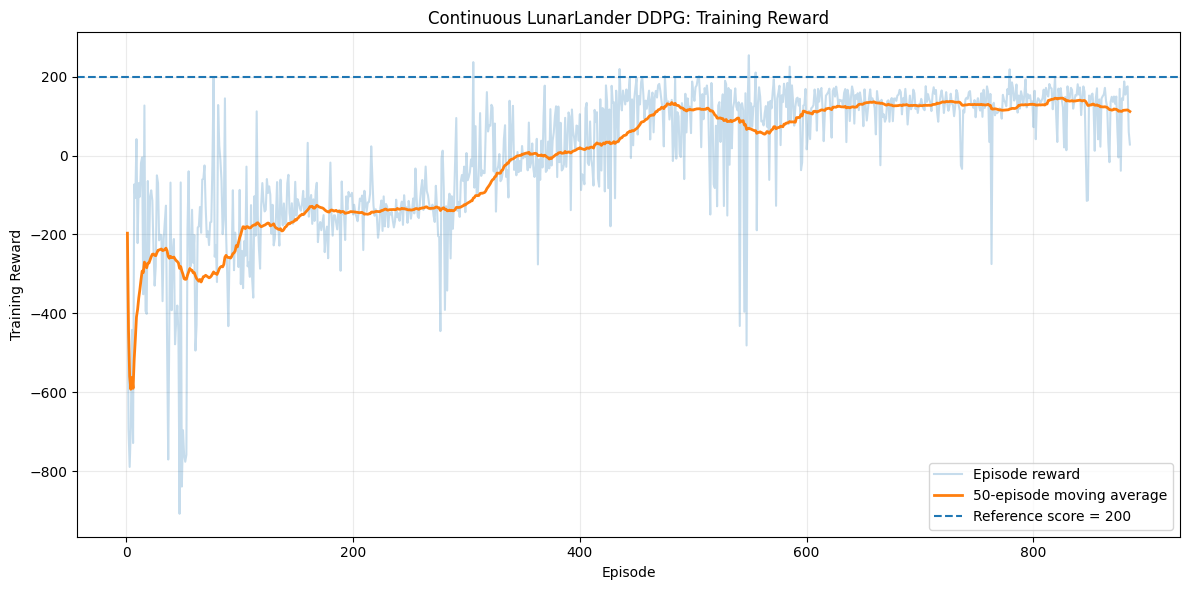

In [17]:
WINDOW = 50
reward_average = history_df["train_reward"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(history_df["episode"], history_df["train_reward"], alpha=0.25, label="Episode reward")
plt.plot(history_df["episode"], reward_average, linewidth=2, label="50-episode moving average")
plt.axhline(200.0, linestyle="--", label="Reference score = 200")
plt.xlabel("Episode")
plt.ylabel("Training Reward")
plt.title("Continuous LunarLander DDPG: Training Reward")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 31. Episode length

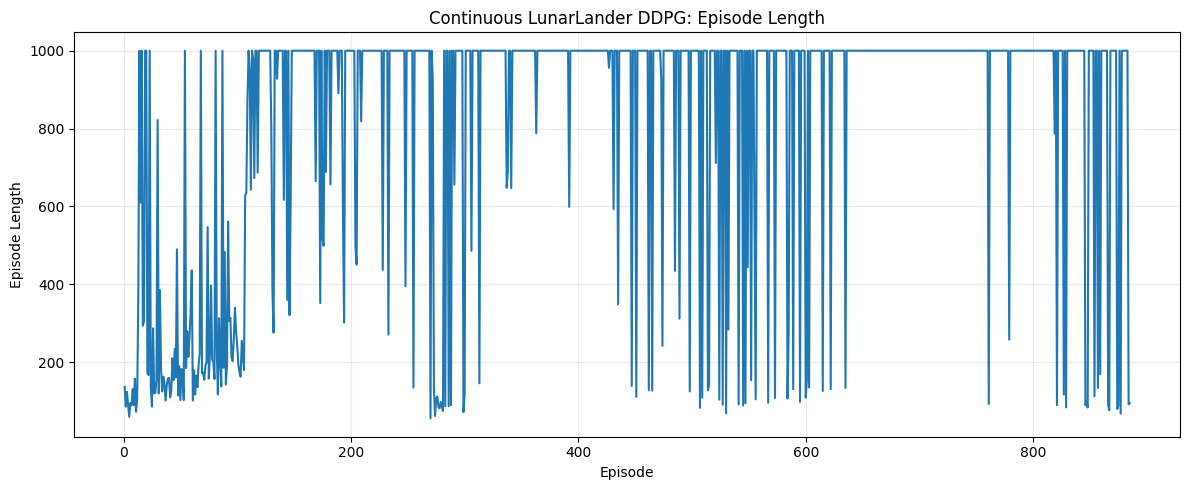

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["train_length"])
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Continuous LunarLander DDPG: Episode Length")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 32. Source-style Average Q

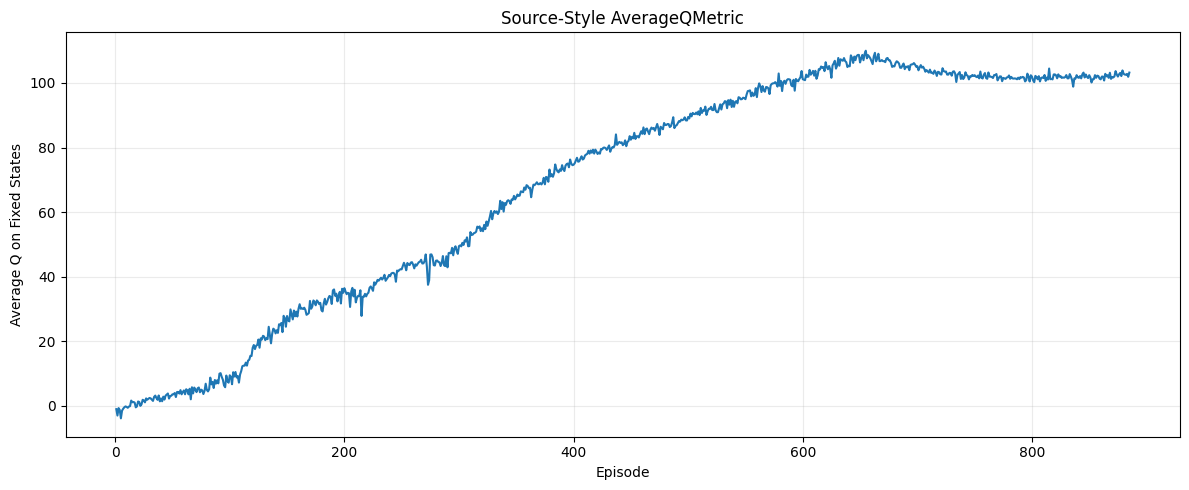

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["average_q"])
plt.xlabel("Episode")
plt.ylabel("Average Q on Fixed States")
plt.title("Source-Style AverageQMetric")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 33. Source-style Absolute Value Error

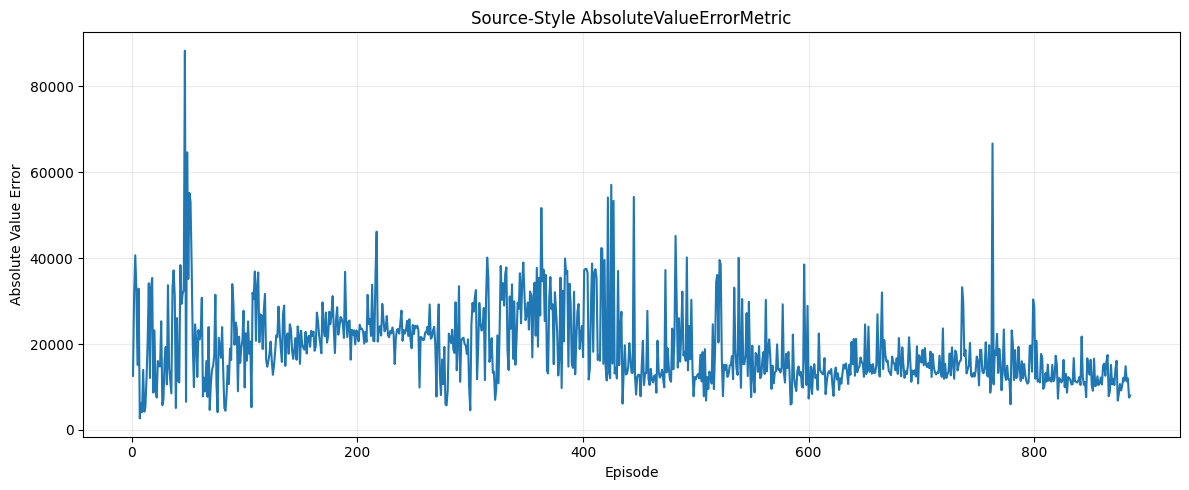

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["absolute_value_error"])
plt.xlabel("Episode")
plt.ylabel("Absolute Value Error")
plt.title("Source-Style AbsoluteValueErrorMetric")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 34. Actor loss

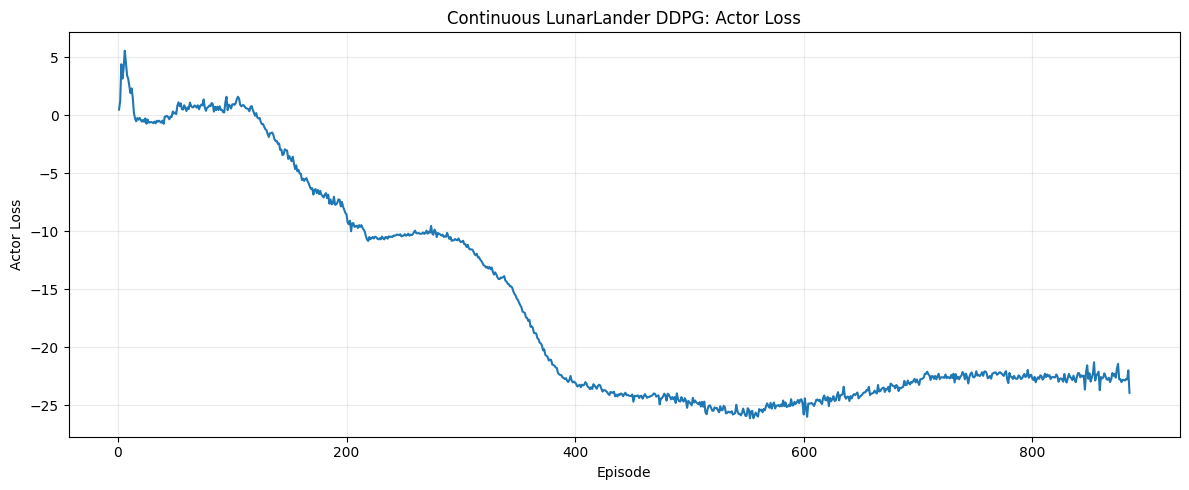

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["actor_loss"])
plt.xlabel("Episode")
plt.ylabel("Actor Loss")
plt.title("Continuous LunarLander DDPG: Actor Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 35. Critic loss

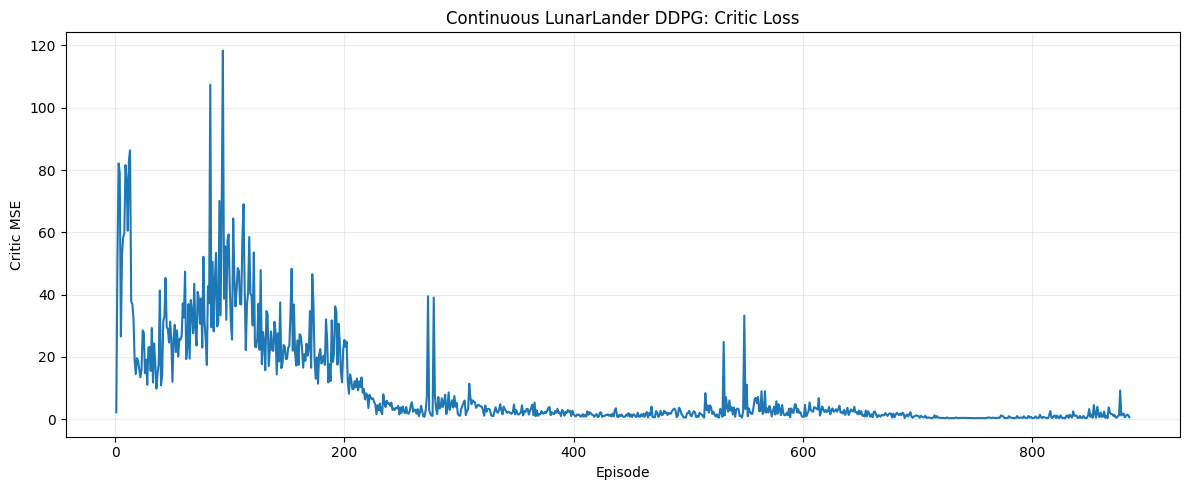

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["critic_loss"])
plt.xlabel("Episode")
plt.ylabel("Critic MSE")
plt.title("Continuous LunarLander DDPG: Critic Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 36. Exploration probability

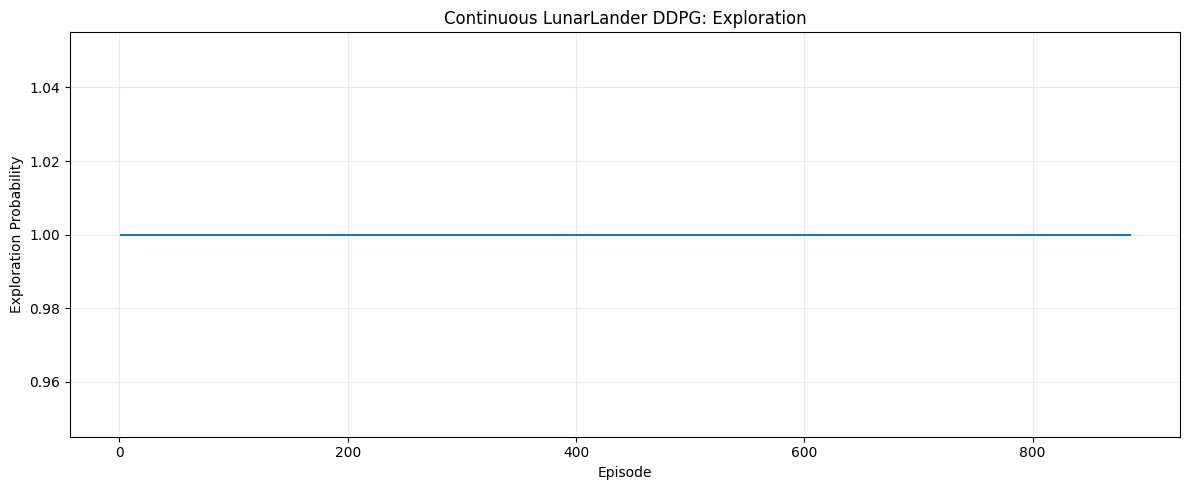

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["exploration"])
plt.xlabel("Episode")
plt.ylabel("Exploration Probability")
plt.title("Continuous LunarLander DDPG: Exploration")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 37. Greedy evaluation reward

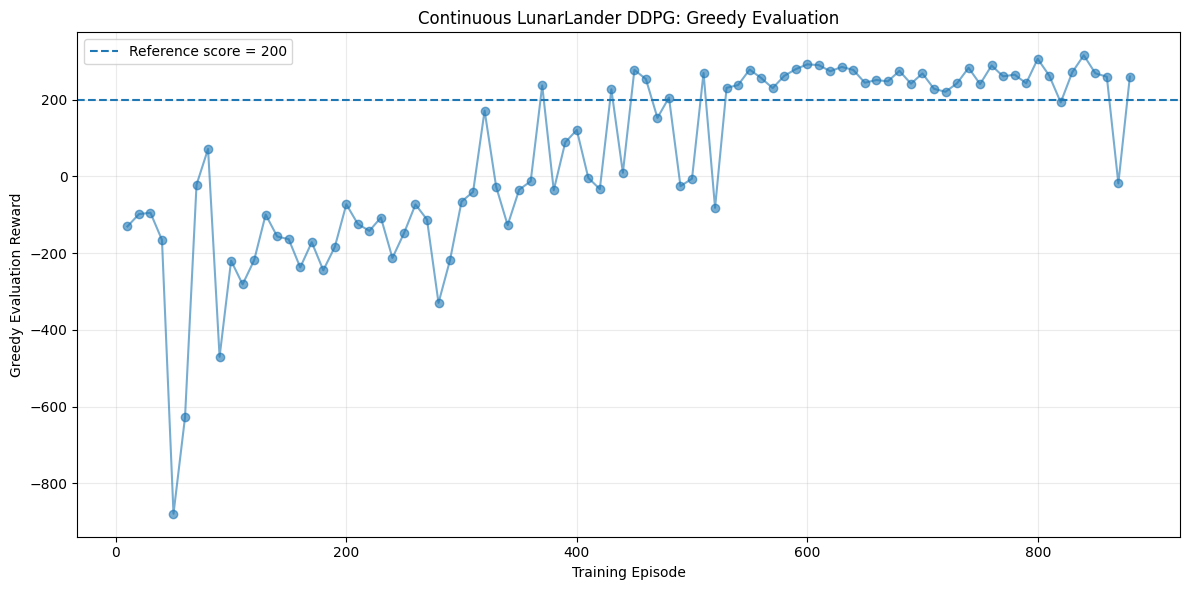

In [24]:
evaluation_df = history_df.dropna(subset=["eval_reward"])
plt.figure(figsize=(12, 6))
plt.plot(evaluation_df["episode"], evaluation_df["eval_reward"], marker="o", alpha=0.6)
plt.axhline(200.0, linestyle="--", label="Reference score = 200")
plt.xlabel("Training Episode")
plt.ylabel("Greedy Evaluation Reward")
plt.title("Continuous LunarLander DDPG: Greedy Evaluation")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 38. Random-policy baseline

In [25]:
def evaluate_random_policy(episodes=20, seed=60000):
    env = gym.make("LunarLander-v3", continuous=True)
    records = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        env.action_space.seed(seed + episode)
        terminated = False
        truncated = False
        total_reward = 0.0
        episode_length = 0
        while not (terminated or truncated):
            action = env.action_space.sample()
            state, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            episode_length += 1
        records.append({"episode": episode + 1, "total_reward": total_reward, "episode_length": episode_length})
    env.close()
    return pd.DataFrame(records)

random_eval_df = evaluate_random_policy()
display(random_eval_df)
print("Random mean reward:", random_eval_df["total_reward"].mean())

,episode,total_reward,episode_length
0,1,-105.8244,104
1,2,-289.4703,133
2,3,-176.3801,113
3,4,-475.0848,117
4,5,-243.7305,84
5,6,-69.0635,98
6,7,-314.7263,100
7,8,-352.1951,133
8,9,-301.1496,81
9,10,-67.0594,96


Random mean reward: -223.9440317059653


## 39. Final greedy evaluation

In [26]:
def evaluate_agent(agent, episodes=20, seed=70000):
    records = []
    for episode in range(episodes):
        total_reward, episode_length = evaluate_one_episode(agent, seed=seed + episode)
        records.append({"episode": episode + 1, "total_reward": total_reward, "episode_length": episode_length})
    return pd.DataFrame(records)

final_eval_df = evaluate_agent(agent, episodes=20)
display(final_eval_df)
print("Mean reward:", final_eval_df["total_reward"].mean())
print("Reward SD:", final_eval_df["total_reward"].std())
print("Mean episode length:", final_eval_df["episode_length"].mean())
print("Episodes with reward >= 200:", int((final_eval_df["total_reward"] >= 200.0).sum()))

,episode,total_reward,episode_length
0,1,282.2123,358
1,2,306.9920,203
2,3,252.4583,150
3,4,267.9895,177
4,5,282.8755,168
5,6,268.4986,193
6,7,261.2641,145
7,8,279.6109,260
8,9,276.6754,175
9,10,274.4275,167


Mean reward: 259.14690951619
Reward SD: 74.01081613041579
Mean episode length: 186.1
Episodes with reward >= 200: 19


## 40. Random policy versus trained DDPG

,Policy,Mean Reward
0,Random,-223.9440
1,Trained DDPG,259.1469


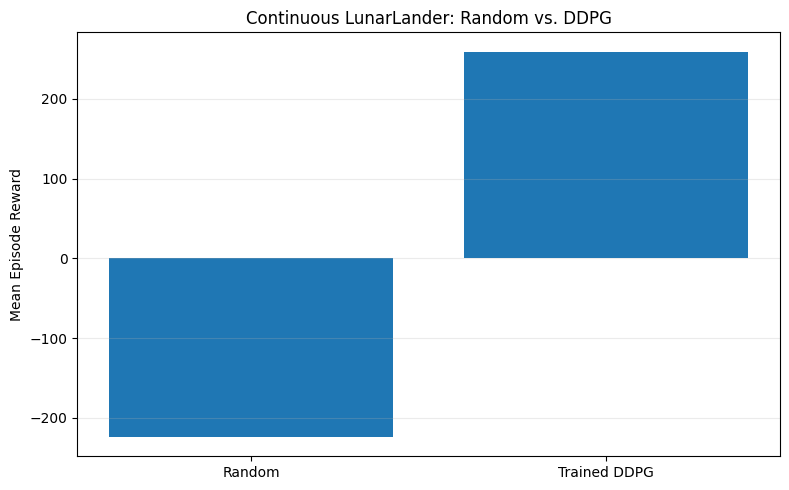

In [27]:
comparison_df = pd.DataFrame({"Policy": ["Random", "Trained DDPG"], "Mean Reward": [random_eval_df["total_reward"].mean(), final_eval_df["total_reward"].mean()]})
display(comparison_df)
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Policy"], comparison_df["Mean Reward"])
plt.ylabel("Mean Episode Reward")
plt.title("Continuous LunarLander: Random vs. DDPG")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 41. Inspect actor and critic output

In [28]:
inspect_env = gym.make("LunarLander-v3", continuous=True)
inspect_state, info = inspect_env.reset(seed=SEED + 999)
inspect_state_tensor = tf.convert_to_tensor(inspect_state[None, :], dtype=tf.float32)
inspect_action = agent.actor_network(inspect_state_tensor).numpy()[0]
inspect_value = agent.critic_network([inspect_state_tensor, tf.convert_to_tensor(inspect_action[None, :], dtype=tf.float32)]).numpy()[0, 0]
print("State:", inspect_state)
print("Actor action:", inspect_action)
print("Critic Q-value:", inspect_value)
inspect_env.close()

State: [-0.0044  1.4197 -0.4473  0.3911  0.0051  0.1013  0.      0.    ]
Actor action: [-1.  1.]
Critic Q-value: 67.82963


## 42. Save and reload

In [29]:
agent.save(AGENT_PATH)
loaded_actor = build_actor()
loaded_critic = build_critic()
loaded_agent = DDPGAgent(loaded_actor, loaded_critic, learn_after_steps=4, replay_size=100000, exploration=1.0, min_exploration=0.01, exploration_decay=1.0, exploration_decay_after=1, discount_factor=0.99, tau=0.001)
loaded_agent.load(AGENT_PATH)
print("Restored exploration:", loaded_agent.exploration)
print("Restored step counter:", loaded_agent.step_counter)
print("Restored replay transitions:", len(loaded_agent.replay_buffer))

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Restored exploration: 1.0
Restored step counter: 731619
Restored replay transitions: 100000


## 43. Record a greedy evaluation video

In [30]:
def record_episode(agent, filename="lunar_lander_continuous_ddpg.mp4", seed=80000, fps=50):
    env = gym.make("LunarLander-v3", continuous=True, render_mode="rgb_array")
    state, info = env.reset(seed=seed)
    frames = [env.render()]
    terminated = False
    truncated = False
    total_reward = 0.0
    episode_length = 0
    while not (terminated or truncated):
        state_tensor = tf.convert_to_tensor(state[None, :], dtype=tf.float32)
        action = agent.actor_network(state_tensor).numpy()[0]
        state, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        total_reward += float(reward)
        episode_length += 1
    env.close()
    imageio.mimsave(filename, frames, fps=fps)
    print("Video saved:", filename)
    print("Reward:", total_reward)
    print("Episode length:", episode_length)
    return filename

video_file = record_episode(agent)
display(Video(video_file, embed=True))

Video saved: lunar_lander_continuous_ddpg.mp4
Reward: 262.0211838307405
Episode length: 688


## 44. Source-faithful algorithm summary

```text
Initialize:
    online actor
    online critic
    cloned target actor
    cloned target critic
    replay memory
    step counter = 1
    exploration = 1

For each episode:

    Reset environment

    Repeat until terminated or truncated:

        actor action = actor(state)

        with probability exploration:
            action = action + environment random action

        execute action

        store:
            state
            action
            reward
            next state
            terminal

        if step counter mod 4 == 0:

            sample replay

            if 64 transitions are available:

                target =
                    reward
                    + gamma
                    * target critic(
                        next state,
                        target actor(next state)
                      )

                update critic using MSE

                update actor using:
                    -mean Q(state, actor(state))

                soft-update actor target

                soft-update critic target

        step counter += 1

    calculate source-style metrics
    decay exploration
```

## 45. What was corrected from the previous notebook?

The previous notebook differed from the supplied source in several places.

This corrected version removes those differences:

| Item | Previous notebook | Corrected notebook |
|---|---|---|
| Replay start | 1,000-transition warm-up | full batch available at 64 |
| Learning frequency | every step | every 4 steps |
| Exploration | Gaussian noise scale | exploration probability + environment random action |
| Critic loss | Huber | MSE |
| Terminal masking | used | not used, matching source |
| Target initialization | copied online weights | cloned model behavior |
| Gradient clipping | used | removed |
| Average Q | training-batch average | fixed-state source metric |
| Error metric | TD error | full-return Absolute Value Error |
| Replay saving | omitted | saved |

## 46. Portfolio interpretation

This notebook now reproduces the supplied `DeepDPG`, replay buffer, metrics, and LunarLanderContinuous wrapper behavior much more closely.

The critical exploration flow is:

```text
actor action
      +
Gym action_space.sample()
      ↓
combined action stored in replay
      ↓
wrapper clips action to [-1, 1]
      ↓
environment receives clipped action
```

The OU process inside `get_randomized_action()` is preserved because it exists in your wrapper source, but it is **not used by `DeepDPG`** because the algorithm calls `get_random_action()` instead.

The notebook also preserves:

- `learn_after_steps = 4`,
- batch size `64`,
- replay capacity `100,000`,
- `gamma = 0.99`,
- `tau = 0.001`,
- actor learning rate `0.0005`,
- critic learning rate `0.001`,
- MSE critic loss,
- source-style target calculation,
- source-style `AverageQMetric`,
- source-style `AbsoluteValueErrorMetric`,
- and replay storage before environment clipping.

## References

1. Lillicrap, T. P., Hunt, J. J., Pritzel, A., et al. (2015). **Continuous control with deep reinforcement learning.** arXiv:1509.02971.

2. Gymnasium documentation: **Lunar Lander**.

3. Supplied project source: `DeepDPG`, `ExperienceReplay`, `GymEnvironment`, and analytics metrics.